## Comparaison de différents modèles supervisés

### A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.

* Déterminer le modèle le plus performant parmi ceux testés.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


In [2]:
X_OHE = pd.read_csv(r"C:\Users\ethan\OpenClassroom\Projet_2\Projet\Anticipez_les_besoins_\Fichiers\data_etape_3_clean_X.csv", keep_default_na=False)
y = pd.read_csv(r"C:\Users\ethan\OpenClassroom\Projet_2\Projet\Anticipez_les_besoins_\Fichiers\data_etape_3_clean_y.csv", keep_default_na=False)

### --- Modèle 1 : DummyRegressor ---


Copies dédiées

In [3]:
X_dummy = X_OHE.copy()
y_dummy = y.copy()

Séparation apprentissage test

In [4]:
Xtr, Xte, ytr, yte = train_test_split(X_dummy, y_dummy, test_size=0.2, random_state=42)

Validation croisée sur le jeu d’apprentissage

In [5]:
scoring = {"r2":"r2", "mae":"neg_mean_absolute_error", "rmse":"neg_root_mean_squared_error"}
cv_res = cross_validate(DummyRegressor(strategy="median"), Xtr, ytr, cv=5, scoring=scoring, return_train_score=False)

cv_r2   = cv_res["test_r2"].mean()
cv_mae  = -cv_res["test_mae"].mean()
cv_rmse = -cv_res["test_rmse"].mean()

Entraînement sur tout le train

In [6]:
dum = DummyRegressor(strategy="median")
dum.fit(Xtr, ytr)

DummyRegressor(strategy='median')

Inférence

In [7]:
yp_tr = dum.predict(Xtr)
yp_te = dum.predict(Xte)

Métriques apprentissage

In [8]:
r2_tr   = r2_score(ytr, yp_tr)
mae_tr  = mean_absolute_error(ytr, yp_tr)
rmse_tr = root_mean_squared_error(ytr, yp_tr)

Métriques test

In [9]:
r2_te   = r2_score(yte, yp_te)
mae_te  = mean_absolute_error(yte, yp_te)
rmse_te = root_mean_squared_error(yte, yp_te)

In [10]:

print(f"Dummy, CV R2 moyen {cv_r2:.3f}, CV MAE moyen {cv_mae:.2f}, CV RMSE moyen {cv_rmse:.2f}")
print(f"Dummy, Train  R2 {r2_tr:.3f}, MAE {mae_tr:.2f}, RMSE {rmse_tr:.2f}")
print(f"Dummy, Test   R2 {r2_te:.3f}, MAE {mae_te:.2f}, RMSE {rmse_te:.2f}")


Dummy, CV R2 moyen -0.124, CV MAE moyen 1595297.94, CV RMSE moyen 2330765.60
Dummy, Train  R2 -0.123, MAE 1594893.67, RMSE 2334513.25
Dummy, Test   R2 -0.156, MAE 1632270.78, RMSE 2296427.92


### --- Modèle 2 : Régression linéaire avec scaling ---



Copies dédiées


In [11]:
X_lin = X_OHE.copy()
y_lin = y.copy()



Séparation apprentissage et test


In [12]:
Xtr, Xte, ytr, yte = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)



Estimateur enveloppe, scaling puis modèle


In [13]:
class ScaleRegressor:
    def __init__(self, model):
        self.model = model
        self.scaler = StandardScaler()
        self.cols_ = None
    def fit(self, X_fit, y_fit):
        self.cols_ = X_fit.columns
        Xs = self.scaler.fit_transform(X_fit)
        self.model.fit(Xs, y_fit)
        return self
    def predict(self, X_new):
        Xs = self.scaler.transform(X_new[self.cols_])
        return self.model.predict(Xs)
    def get_params(self, deep=True):
        return {"model": self.model}
    def set_params(self, **params):
        for k,v in params.items(): setattr(self, k, v)
        return self

est = ScaleRegressor(LinearRegression())



Validation croisée sur le jeu d’apprentissage


In [14]:
scoring = {"r2":"r2", "mae":"neg_mean_absolute_error", "rmse":"neg_root_mean_squared_error"}
cv_res = cross_validate(est, Xtr, ytr, cv=5, scoring=scoring, return_train_score=False)

cv_r2   = cv_res["test_r2"].mean()
cv_mae  = -cv_res["test_mae"].mean()
cv_rmse = -cv_res["test_rmse"].mean()



Entraînement complet


In [15]:
est.fit(Xtr, ytr)


Inférence


In [16]:
yp_tr = est.predict(Xtr)
yp_te = est.predict(Xte)


Métriques


In [17]:
r2_tr   = r2_score(ytr, yp_tr);  mae_tr  = mean_absolute_error(ytr, yp_tr);  rmse_tr = root_mean_squared_error(ytr, yp_tr)
r2_te   = r2_score(yte, yp_te);  mae_te  = mean_absolute_error(yte, yp_te);  rmse_te = root_mean_squared_error(yte, yp_te)

In [18]:

print(f"LIN, CV R2 moyen {cv_r2:.3f}, CV MAE moyen {cv_mae:.2f}, CV RMSE moyen {cv_rmse:.2f}")
print(f"LIN, Train  R2 {r2_tr:.3f}, MAE {mae_tr:.2f}, RMSE {rmse_tr:.2f}")
print(f"LIN, Test   R2 {r2_te:.3f}, MAE {mae_te:.2f}, RMSE {rmse_te:.2f}")


LIN, CV R2 moyen -1621836246267546112932970496.000, CV MAE moyen 6666178352110102528.00, CV RMSE moyen 60907623709502980096.00
LIN, Train  R2 0.707, MAE 877942.23, RMSE 1192728.70
LIN, Test   R2 -4201625087133486069841920.000, MAE 453223052686615296.00, RMSE 4377450407927869440.00


### --- Modèle 3 : SVR avec scaling ---


Copies dédiées

In [19]:
X_svr = X_OHE.copy()
y_svr = y.copy()

Séparation apprentissage et test

In [20]:
Xtr, Xte, ytr, yte = train_test_split(X_svr, y_svr, test_size=0.2, random_state=42)

Estimateur: SVR dans ton wrapper de scaling

In [21]:
est = ScaleRegressor(SVR(kernel="rbf", C=10.0, epsilon=0.1, gamma="scale"))

Validation croisée sur le jeu d’apprentissage

In [22]:
scoring = {"r2":"r2", "mae":"neg_mean_absolute_error", "rmse":"neg_root_mean_squared_error"}
cv_res = cross_validate(est, Xtr, ytr, cv=5, scoring=scoring, return_train_score=False)

cv_r2   = cv_res["test_r2"].mean()
cv_mae  = -cv_res["test_mae"].mean()
cv_rmse = -cv_res["test_rmse"].mean()

c:\Users\ethan\Anconda4\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ethan\Anconda4\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ethan\Anconda4\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ethan\Anconda4\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), 

Entraînement complet

In [23]:
est.fit(Xtr, ytr)

c:\Users\ethan\Anconda4\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Inférence

In [24]:
yp_tr = est.predict(Xtr)
yp_te = est.predict(Xte)

Métriques

In [25]:
r2_tr   = r2_score(ytr, yp_tr);  mae_tr  = mean_absolute_error(ytr, yp_tr);  rmse_tr = root_mean_squared_error(ytr, yp_tr)
r2_te   = r2_score(yte, yp_te);  mae_te  = mean_absolute_error(yte, yp_te);  rmse_te = root_mean_squared_error(yte, yp_te)

In [26]:
print(f"SVR, CV R2 moyen {cv_r2:.3f}, CV MAE moyen {cv_mae:.2f}, CV RMSE moyen {cv_rmse:.2f}")
print(f"SVR, Train  R2 {r2_tr:.3f}, MAE {mae_tr:.2f}, RMSE {rmse_tr:.2f}")
print(f"SVR, Test   R2 {r2_te:.3f}, MAE {mae_te:.2f}, RMSE {rmse_te:.2f}")

SVR, CV R2 moyen -0.124, CV MAE moyen 1595259.73, CV RMSE moyen 2330712.92
SVR, Train  R2 -0.123, MAE 1594836.67, RMSE 2334420.37
SVR, Test   R2 -0.156, MAE 1632220.99, RMSE 2296354.05


### --- Modèle 4 : RandomForestRegressor ---


Copies dédiées

In [27]:
X_rf = X_OHE.copy()
y_rf = y.copy()


Séparation apprentissage et test

In [28]:
Xtr, Xte, ytr, yte = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)



Estimateur Forêt Aléatoire


In [29]:
est = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

Validation croisée sur le jeu d’apprentissage

In [30]:
scoring = {"r2":"r2", "mae":"neg_mean_absolute_error", "rmse":"neg_root_mean_squared_error"}
cv_res = cross_validate(est, Xtr, ytr, cv=5, scoring=scoring, return_train_score=False)

cv_r2   = cv_res["test_r2"].mean()
cv_mae  = -cv_res["test_mae"].mean()
cv_rmse = -cv_res["test_rmse"].mean()


c:\Users\ethan\Anconda4\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\ethan\Anconda4\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\ethan\Anconda4\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\ethan\Anconda4\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exa


Entraînement complet


In [31]:
est.fit(Xtr, ytr)


c:\Users\ethan\Anconda4\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(n_estimators=400, n_jobs=-1, random_state=42)


Inférence


In [32]:
yp_tr = est.predict(Xtr)
yp_te = est.predict(Xte)


Métriques


In [33]:
r2_tr   = r2_score(ytr, yp_tr);  mae_tr  = mean_absolute_error(ytr, yp_tr);  rmse_tr = root_mean_squared_error(ytr, yp_tr)
r2_te   = r2_score(yte, yp_te);  mae_te  = mean_absolute_error(yte, yp_te);  rmse_te = root_mean_squared_error(yte, yp_te)

In [34]:
print(f"RF, CV R2 moyen {cv_r2:.3f}, CV MAE moyen {cv_mae:.2f}, CV RMSE moyen {cv_rmse:.2f}")
print(f"RF, Train  R2 {r2_tr:.3f}, MAE {mae_tr:.2f}, RMSE {rmse_tr:.2f}")
print(f"RF, Test   R2 {r2_te:.3f}, MAE {mae_te:.2f}, RMSE {rmse_te:.2f}")

RF, CV R2 moyen 0.570, CV MAE moyen 1014901.44, CV RMSE moyen 1439033.39
RF, Train  R2 0.944, MAE 369948.35, RMSE 523248.82
RF, Test   R2 0.452, MAE 1113843.86, RMSE 1581255.83


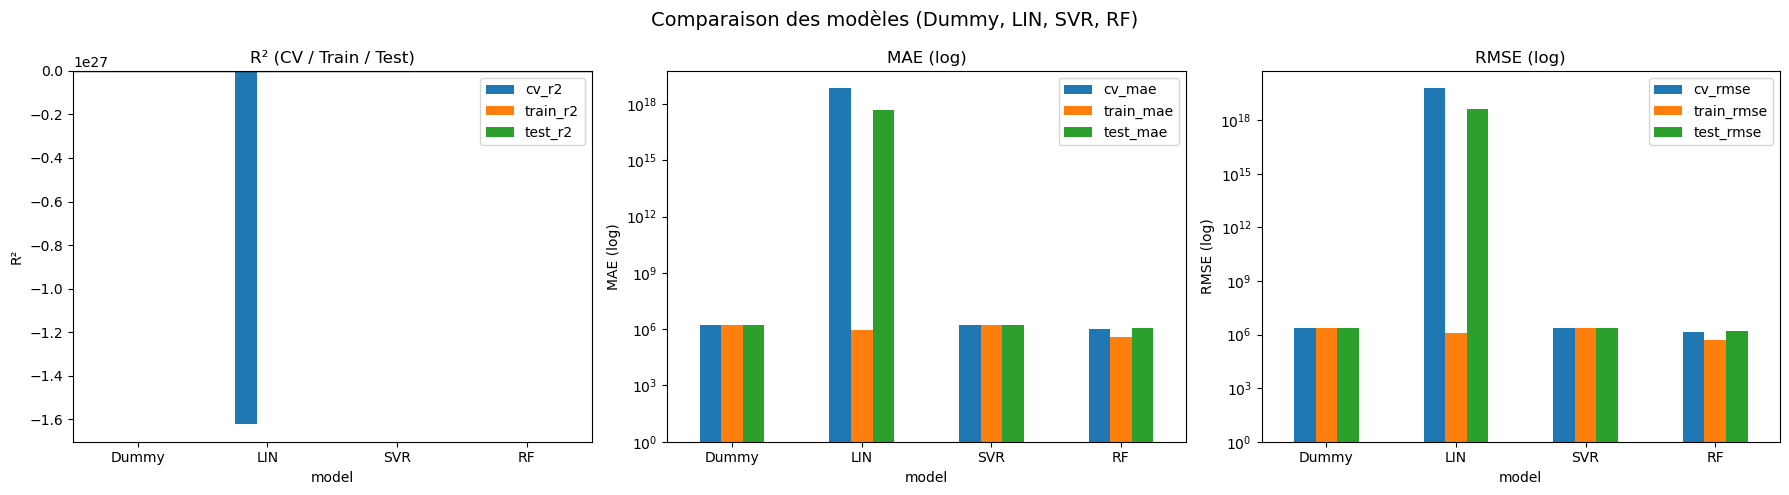

In [ ]:

# Données des modèles
data = {
    "model": ["Dummy", "LIN", "SVR", "RF"],
    "cv_r2":      [-0.124, -1621836246267546112932970496.0,  -0.124,  0.570],
    "train_r2":   [-0.123,  0.707,                           -0.123,  0.944],
    "test_r2":    [-0.156, -4201625087133486069841920.0,     -0.156,  0.452],
    "cv_mae":     [1595297.94,          6666178352110102528.0,       1595259.73, 1014901.44],
    "train_mae":  [1594893.67,          877942.23,                    1594836.67, 369948.35],
    "test_mae":   [1632270.78,          453223052686615296.0,         1632220.99, 1113843.86],
    "cv_rmse":    [2330765.60,          60907623709502980096.0,       2330712.92, 1439033.39],
    "train_rmse": [2334513.25,          1192728.70,                   2334420.37, 523248.82],
    "test_rmse":  [2296427.92,          4377450407927869440.0,        2296354.05, 1581255.83],
}

df = pd.DataFrame(data).set_index("model")

# Figure unique avec 3 sous-graphiques
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) R²
df[["cv_r2", "train_r2", "test_r2"]].plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("R² (CV / Train / Test)")
axes[0].set_ylabel("R²")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].tick_params(axis="x", rotation=0)

# 2) MAE (échelle log)
df[["cv_mae", "train_mae", "test_mae"]].plot(
    kind="bar",
    ax=axes[1],
    log=True
)
axes[1].set_title("MAE (log)")
axes[1].set_ylabel("MAE (log)")
axes[1].tick_params(axis="x", rotation=0)

# 3) RMSE (échelle log)
df[["cv_rmse", "train_rmse", "test_rmse"]].plot(
    kind="bar",
    ax=axes[2],
    log=True
)
axes[2].set_title("RMSE (log)")
axes[2].set_ylabel("RMSE (log)")
axes[2].tick_params(axis="x", rotation=0)

fig.suptitle("Comparaison des modèles (Dummy, LIN, SVR, RF)", fontsize=14)
fig.tight_layout()
plt.show()


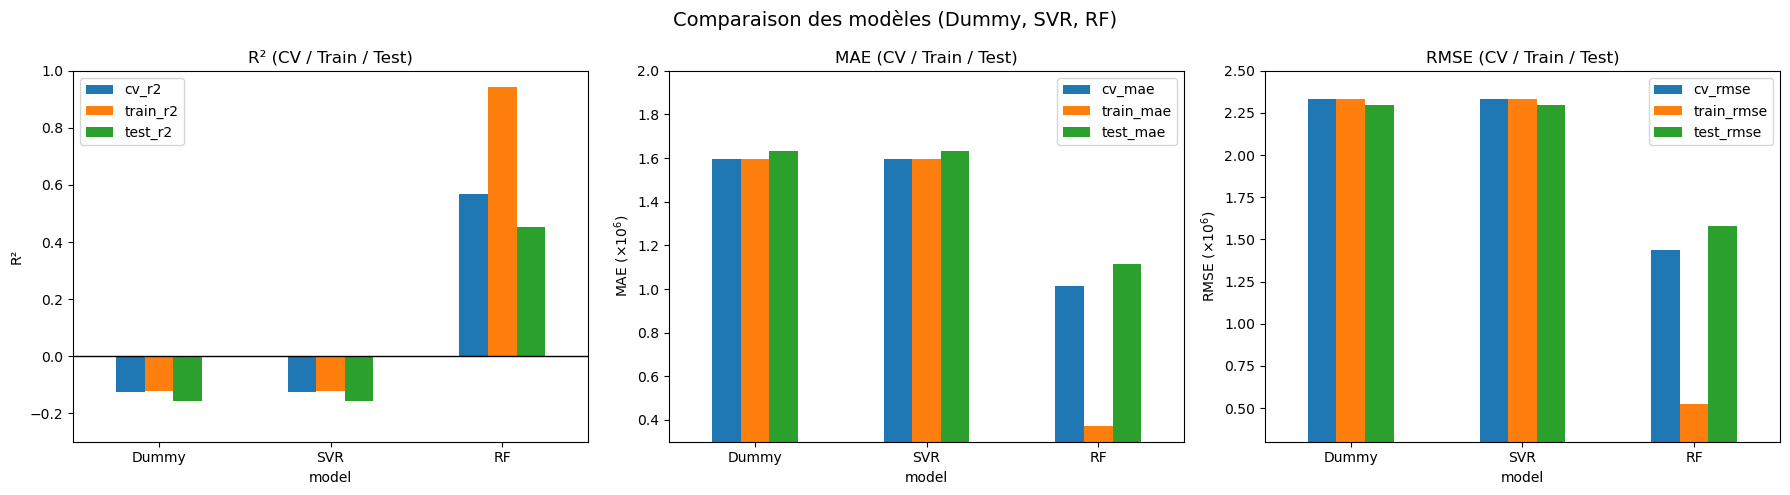

In [43]:
data = {
    "model": ["Dummy", "SVR", "RF"],
    "cv_r2":      [-0.124,  -0.124,  0.570],
    "train_r2":   [-0.123,  -0.123,  0.944],
    "test_r2":    [-0.156,  -0.156,  0.452],
    "cv_mae":     [1595297.94, 1595259.73, 1014901.44],
    "train_mae":  [1594893.67, 1594836.67, 369948.35],
    "test_mae":   [1632270.78, 1632220.99, 1113843.86],
    "cv_rmse":    [2330765.60, 2330712.92, 1439033.39],
    "train_rmse": [2334513.25, 2334420.37, 523248.82],
    "test_rmse":  [2296427.92, 2296354.05, 1581255.83],
}

df = pd.DataFrame(data).set_index("model")

# MAE et RMSE mis à l'échelle (÷ 1e6)
df_mae_scaled  = df[["cv_mae", "train_mae", "test_mae"]]   / 1e6
df_rmse_scaled = df[["cv_rmse", "train_rmse", "test_rmse"]] / 1e6

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) R²
df[["cv_r2", "train_r2", "test_r2"]].plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("R² (CV / Train / Test)")
axes[0].set_ylabel("R²")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_ylim(-0.3, 1.0)
axes[0].tick_params(axis="x", rotation=0)

# 2) MAE (÷ 1e6, mention ×10^6 dans le label)
df_mae_scaled.plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_title("MAE (CV / Train / Test)")
axes[1].set_ylabel(r"MAE ($\times 10^6$)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].set_ylim(0.3, 2.0)

# 3) RMSE (÷ 1e6, mention ×10^6 dans le label)
df_rmse_scaled.plot(
    kind="bar",
    ax=axes[2]
)
axes[2].set_title("RMSE (CV / Train / Test)")
axes[2].set_ylabel(r"RMSE ($\times 10^6$)")
axes[2].tick_params(axis="x", rotation=0)
axes[2].set_ylim(0.3, 2.5)

fig.suptitle("Comparaison des modèles (Dummy, SVR, RF)", fontsize=14)
fig.tight_layout()
fig.savefig(
    r"C:\Users\ethan\OpenClassroom\Projet_2\Projet\Anticipez_les_besoins_\Graphs\comparaison_modeles_dummy_svr_rf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
